In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

from sklearn.metrics import confusion_matrix

### Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Preprocessing

In [3]:
# Reshape
x_train = x_train.reshape(-1,28,28,1).astype('float32') / 255
x_test = x_test.reshape(-1,28,28,1).astype('float32') / 255

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

### model

In [4]:
input_layer = Input(shape=(28,28,1))

x = Conv2D(32, (3,3), activation='relu')(input_layer)
x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.5)(x)

x = Flatten()(x)
x = Dense(250, activation='sigmoid')(x)

output_layer = Dense(10, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)

### Compile Model

In [5]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Train Model

In [6]:
model.fit(x_train, y_train_cat,
          epochs=10,
          batch_size=128,
          validation_data=(x_test, y_test_cat))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 162s 342ms/step - accuracy: 0.9410 - loss: 0.2060 - val_accuracy: 0.9840 - val_loss: 0.0545
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 189s 313ms/step - accuracy: 0.9831 - loss: 0.0591 - val_accuracy: 0.9867 - val_loss: 0.0393
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 307ms/step - accuracy: 0.9878 - loss: 0.0414 - val_accuracy: 0.9893 - val_loss: 0.0322
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 307ms/step - accuracy: 0.9909 - loss: 0.0311 - val_accuracy: 0.9902 - val_loss: 0.0304
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 308ms/step - accuracy: 0.9924 - loss: 0.0246 - val_accuracy: 0.9900 - val_loss: 0.0286
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 307ms/step - accuracy: 0.9944 - loss: 0.0194 - val_accuracy: 0.9921 - val_loss: 0.0266
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 148s 316ms/step - accuracy: 0.9955 - loss: 0.0164 - val_accuracy: 0.9922 - val_loss: 0.0255
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 307ms/step - accuracy: 0.9956 -

### Evaluate Model

In [7]:
loss, accuracy = model.evaluate(x_test, y_test_cat)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9924 - loss: 0.0260
Test Accuracy: 0.9923999905586243


### Predictions

In [8]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


### Confusion Matrix

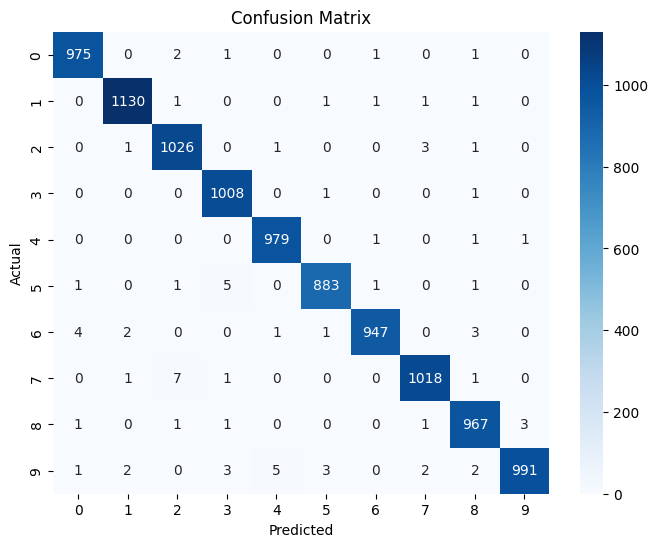

In [9]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Sample Prediction Visualisation

Actual: 7
Predicted: 7


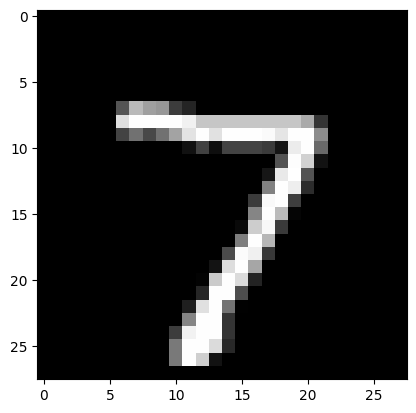

In [10]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
print("Actual:", y_test[0])
print("Predicted:", y_pred_classes[0])

📌 Code Overview: Multiclass Classification using CNN (MNIST Dataset)

This implementation focuses on building a multiclass image classifier using a Convolutional Neural Network (CNN) on the MNIST dataset. The model is trained to classify handwritten digits (0–9) into one of ten classes.

🔹 1. Dataset Loading

The MNIST dataset is loaded using TensorFlow/Keras. It consists of 70,000 grayscale images (28×28 pixels) of handwritten digits, divided into 60,000 training samples and 10,000 testing samples.

🔹 2. Data Preprocessing
Images are reshaped to include a channel dimension (28×28×1) for CNN compatibility.
Pixel values are normalized to the range [0,1] to improve training efficiency.
Target labels are converted into one-hot encoded vectors for multiclass classification.
🔹 3. Model Architecture

A CNN model is constructed using the Functional API with the following layers:

Convolutional Layers (Conv2D) → Extract features such as edges and patterns
MaxPooling Layer → Reduces spatial dimensions and computation
Dropout Layer → Prevents overfitting
Flatten Layer → Converts feature maps into a 1D vector
Dense Layers → Perform classification
Output Layer (Softmax Activation) → Produces probabilities for 10 classes
🔹 4. Model Compilation

The model is compiled with:

Optimizer: Adam
Loss Function: Categorical Crossentropy
Evaluation Metric: Accuracy
🔹 5. Model Training

The CNN is trained on the training dataset using:

Multiple epochs
Batch processing
Validation using test data to monitor performance
🔹 6. Model Evaluation

The trained model is evaluated on the test dataset to measure accuracy and loss, ensuring its ability to generalize to unseen data.

🔹 7. Prediction and Confusion Matrix
The model predicts classes for test images.
A confusion matrix is generated to evaluate classification performance across all classes by comparing actual vs predicted labels.
This helps identify misclassifications and understand model accuracy in detail.
🎯 Key Concept

CNNs automatically learn hierarchical features from images, making them highly effective for multiclass classification tasks such as handwritten digit recognition.

🧠 One-Line Summary

👉 Image → Normalize → CNN → Softmax → Multiclass Prediction → Confusion Matrix